# Kaggle Competition foe MAE of test
## Importing of Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV,Lasso,Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error , r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, PowerTransformer, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import GridSearchCV, train_test_split

## Data Dictionary

| Feature | Description |
| :--- | :--- |
| **Property_id** | A unique identifier for each listing. |
| **Offer** | The type of listing (e.g., For Rent). |
| **URL** | The original source link for the listing. |
| **Property_type** | Type of residence (e.g., Apartment, Villa, Studio). |
| **Include_w_e** | Whether Electricity and Water (EWA) are included in the price. |
| **Title** | The headline of the listing (contains descriptive keywords). |
| **Area** | The specific neighborhood (e.g., Juffair, Saar, Amwaj). |
| **Governorate** | The administrative region (e.g., Capital, Muharraq, Northern, Southern). |
| **Beds** | Number of bedrooms. |
| **Baths** | Number of bathrooms. |
| **Size** | The total area of the property. |
| **Availability_date** | When the property is ready for move-in. |
| **Agent_name** | The name of the listing agent. |
| **Agency** | The name of the agency. |
| **Amenities** | The number of features (e.g., Swimming Pool, Gym -> 2). |
| **rent** | Target Variable. The monthly rental price in BHD. |

In [2]:
df = pd.read_csv('./data/data.csv')
df.shape

(10578, 16)

In [3]:
df.isnull().sum()

Property_id            0
Offer                  0
URL                    0
Property_type          0
Include_w_e            0
Title                  3
Area                   3
Governorate            3
Beds                   0
Baths                  0
Size                   0
Availability_date    519
Agent_name             3
Agency                 3
Amenities            306
rent                   3
dtype: int64

## EDA

In [4]:
df = df.dropna(subset=['rent'])

df['Availability_date'] = pd.to_datetime(df['Availability_date'], format ='%d %b %Y', errors = 'coerce')

df['Beds'] = df['Beds'].replace({'studio': 1, '%+ Maid': 1, 'studio+ Maid': 2, '%++ Maid': 1})
df['Beds'] = pd.to_numeric(df['Beds'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')

df['Baths'] = pd.to_numeric(df['Baths'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')
df['Baths'] = df['Baths'].fillna(df['Baths'].median())

# df['Amenities'] = df['Amenities'].fillna(df['Amenities'].median())

In [5]:
df['Size_sqft'] = df['Size'].astype(str).str.extract(r'([\d,]+)\s*sqft')[0].str.replace(',', '')
df['Size_sqft'] = pd.to_numeric(df['Size_sqft'], errors='coerce')
df['Size_sqft'] = df['Size_sqft'].fillna(df['Size_sqft'].median())

df['Size_sqm'] = df['Size'].astype(str).str.extract(r'/\s*([\d,]+)\s*sqm')[0].str.replace(',', '')
df['Size_sqm'] = pd.to_numeric(df['Size_sqm'], errors='coerce')
df['Size_sqm'] = df['Size_sqm'].fillna(df['Size_sqm'].median())

df.drop(columns=['Size'],inplace = True)

df['Governorate'] = df['Governorate'].fillna('Unknown').astype(str)
df['Property_type'] = df['Property_type'].fillna('Unknown').astype(str)

In [6]:
print(df['Area'].nunique())
print(df['Area'].isnull().sum())
print(df['Area'].value_counts())

127
0
Area
Al Juffair                                              1914
Seef                                                    1025
Saar                                                     704
Janabiya                                                 535
Hidd                                                     496
                                                        ... 
Buri                                                       1
Al Thurya villa Diyar Al Muharraq, Diyar Al Muharraq       1
Dareena, Dilmunia Island                                   1
Wahat Al Muharraq                                          1
Adhari, Manama                                             1
Name: count, Length: 127, dtype: int64


In [7]:
rare_areas = df['Area'].value_counts()[lambda x: x < 10].index

df['Area_grouped'] = df['Area'].replace(rare_areas, 'Other')

print('Original unique areas: ', df['Area'].nunique())
print('Grouped unique areas: ', df['Area_grouped'].nunique())

Original unique areas:  127
Grouped unique areas:  87


In [8]:
rare_props = df['Property_type'].value_counts()[lambda x: x < 5].index
df['Property_type_grouped'] = df['Property_type'].replace(rare_props, 'Other')

In [9]:
#Extract keywords form the title column
keywords = ['sea view', 'navy approved', 'private pool', 'balcony', 
    'fully furnished', 'semi furnished', 'unfurnished', 
    'duplex', 'luxury', 'beach access']

for kw in keywords:
    col_name = f'kw_{kw.replace(" ", "_")}'
    df[col_name] = df['Title'].str.lower().str.contains(kw, na=False).astype(int)

kw_cols = [f'kw_{kw.replace(" ", "_")}' for kw in keywords]

In [10]:
upper_b = df['rent'].quantile(0.998) #setting upper limit to realistic number with testing quantile function
lower_b = df['rent'].quantile(0.001) #setting lower limit to realistic number with testing quantile function

print(f"Upper bound: {upper_b:.2f} BHD")
print(f"Lower bound: {lower_b:.2f} BHD")

Upper bound: 5213.00 BHD
Lower bound: 100.00 BHD


In [11]:
df = df[(df['rent'] >= lower_b) & (df['rent'] <= upper_b)]

In [12]:
df = df[df['Size_sqm'] > 30]

## Feature Engineering

In [13]:
df['sqm_per_bed'] = df['Size_sqm'] / (df['Beds'] + 1)
df['bath_bed_ratio'] = df['Baths'] / (df['Beds'] + 1)

In [14]:
df.shape

(10410, 31)

## Heatmap and Histogram Plotting

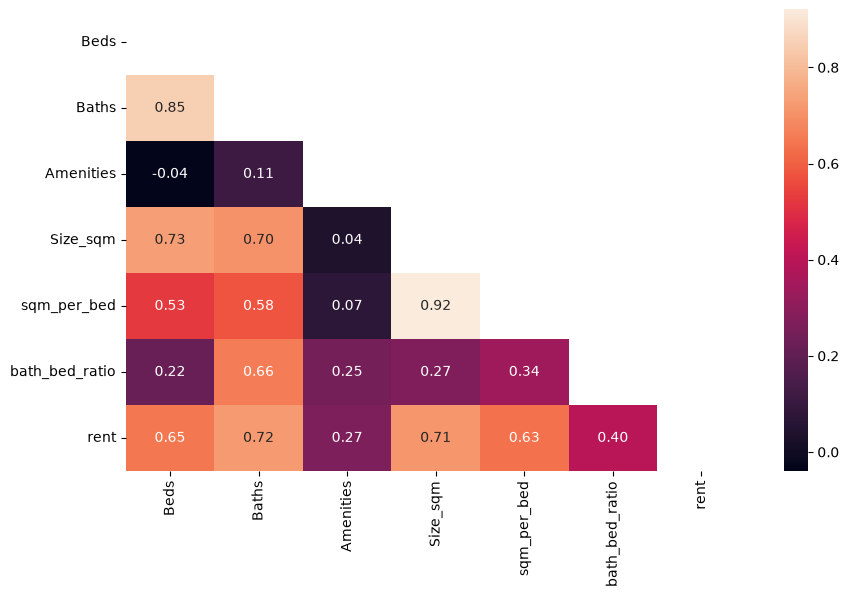

In [15]:
plt.figure(figsize=(10, 6))

num_cols = ['Beds', 'Baths', 'Amenities', 'Size_sqm','sqm_per_bed','bath_bed_ratio','rent']
corr_= df[num_cols].corr()

sns.heatmap(
    corr_, 
    annot=True,
    mask=np.triu(corr_), 
    fmt='.2f'
)
plt.show()

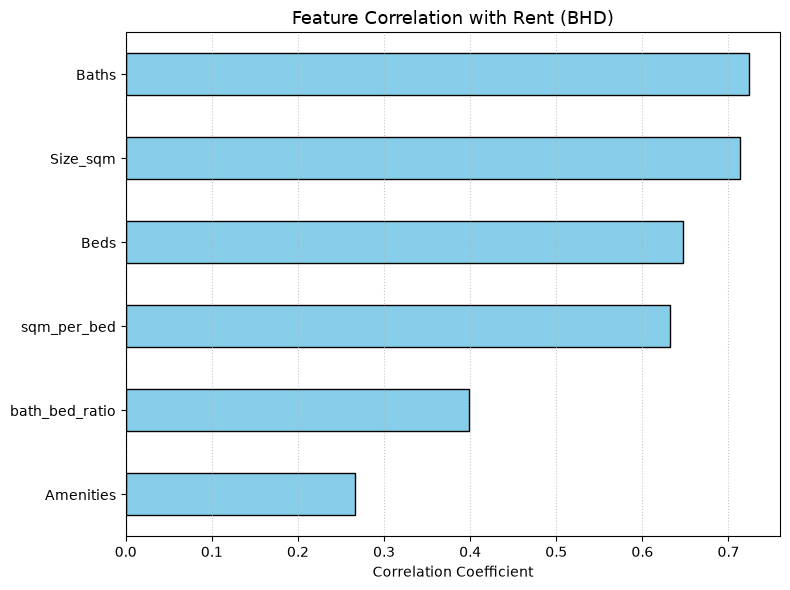

In [16]:
plt.figure(figsize=(8, 6))

# Calculate correlation with rent specifically and sort
rent_corr = df[num_cols].corr()['rent'].drop('rent').sort_values(ascending=True)

rent_corr.plot(kind='barh', color='skyblue', edgecolor='black')
plt.title('Feature Correlation with Rent (BHD)', fontsize=13)
plt.xlabel('Correlation Coefficient')
plt.axvline(0, color='red', linestyle='--', linewidth=0.8) # Reference line at 0
plt.grid(axis='x', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

In [17]:
#Skewness of the rent(target) column, right-skewed
skewness = df['rent'].skew()
skewness

np.float64(2.81951971632648)

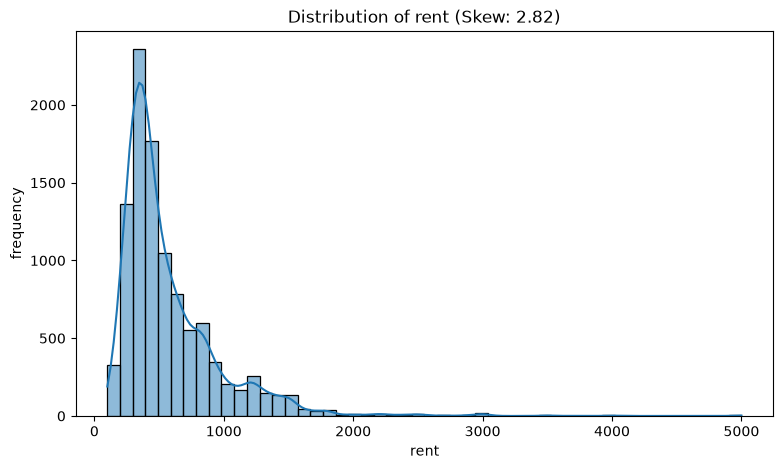

In [18]:
plt.figure(figsize=(9, 5))
sns.histplot(df['rent'],bins = 50, kde = True)
plt.title(f"Distribution of rent (Skew: {skewness:.2f})")
plt.xlabel("rent")
plt.ylabel("frequency")
plt.show()

In [19]:
df.head()

,Property_id,Offer,URL,Property_type,Include_w_e,Title,Area,Governorate,Beds,Baths,...,kw_private_pool,kw_balcony,kw_fully_furnished,kw_semi_furnished,kw_unfurnished,kw_duplex,kw_luxury,kw_beach_access,sqm_per_bed,bath_bed_ratio
0,6046,Rent,https://www.propertyfinder.bh/en/plp/rent/vill...,Villa,Inclusive,BTRAND NEW LUXURY VILLA FOR RENT AMWAJ,"Amwaj Avenue, Amwaj Islands",Muharraq Governorate,3,4.0,...,0,0,0,0,0,0,1,0,55.0,1.000000
1,2240,Rent,https://www.propertyfinder.bh/en/plp/rent/vill...,Villa,Exclusive,First Resident | Quiet Area | Luxurious,Diyar Al Muharraq,Muharraq Governorate,5,6.0,...,0,0,0,0,0,0,0,0,50.0,1.000000
2,6248,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Inclusive,Studio Apartment for rent located in Juffair,Al Juffair,Capital Governorate,1,1.0,...,0,0,0,0,0,0,0,0,22.5,0.500000
3,7177,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Exclusive,Apartment for Rent in Jidhafs – Prime Location,Jidhafs,Northern Governorate,3,3.0,...,0,0,0,0,0,0,0,0,35.0,0.750000
4,7842,Rent,https://www.propertyfinder.bh/en/plp/rent/vill...,Villa,Exclusive,Navy Approved| 5 BR | Private Pool |Gardens,Al Juffair,Capital Governorate,5,5.0,...,1,0,0,0,0,0,0,0,75.0,0.833333


## Model intialization

In [20]:
num_features = ['Beds', 'Baths', 'Amenities', 'Size_sqm',
                'sqm_per_bed','bath_bed_ratio'] + kw_cols
cat_features = ['Governorate', 'Property_type_grouped','Area_grouped','Include_w_e']

X = df[num_features + cat_features]
y = df['rent']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
#Tranform y_train becuase of right-skewness using log1p
y_train_log = np.log1p(y_train)

In [22]:
cat_trans = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [23]:
pipe_cat = Pipeline(
    steps=[
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop = 'first'))
])

In [ ]:
pipe_num = Pipeline(
    steps=[
        ('knn',KNNImputer(n_neighbors=5)),
        ('scaler', StandardScaler())
    ]
)

In [24]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num',pipe_num, num_features),
        ('cat', pipe_cat, cat_features)
    ]
)

In [26]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        random_state=42, n_jobs=-1))
])

In [28]:
param_grid = {
    'preprocessor__num__knn__n_neighbors': [3, 5, 7], 
    'regressor__n_estimators': [400, 500, 600],
    'regressor__max_depth': [25, 30, 35],
    'regressor__min_samples_split': [3, 5],
    'regressor__min_samples_leaf': [1, 2],
    'regressor__max_features': ['sqrt', 0.8]}

In [29]:
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

In [30]:
#alphas = np.logspace(-3,3,100)
# model_pipeline = Pipeline(steps=[
#     ('preprocessor',preprocessor),
#     ('regressor',RandomForestRegressor(
#         n_estimators=200, max_depth=20, 
#         random_state=42, n_jobs=-1))
# ])
#RidgeCV(alphas=alphas , cv = 5)
#RandomForestRegressor( n_estimators=200, max_depth=20,  random_state=42, n_jobs=-1)

In [32]:
grid_search.fit(X_train, y_train_log)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'regressor__max_depth': [20, 25, ...], 'regressor__max_features': ['sqrt', 0.7, ...], 'regressor__min_samples_leaf': [1, 2], 'regressor__min_samples_split': [3, 4, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to

In [33]:
grid_search.best_params_

{'regressor__max_depth': 30,
 'regressor__max_features': 'sqrt',
 'regressor__min_samples_leaf': 1,
 'regressor__min_samples_split': 3,
 'regressor__n_estimators': 400}

In [34]:
best_rf_model = grid_search.best_estimator_

In [35]:
y_pred_train_log = best_rf_model.predict(X_train)
y_pred_test_log = best_rf_model.predict(X_test)

y_pred_train = np.expm1(y_pred_train_log)
y_pred_test = np.expm1(y_pred_test_log)

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

MAE_train = mean_absolute_error(y_train, y_pred_train)
MAE_test = mean_absolute_error(y_test, y_pred_test)

print(f"Train R2 Score: {r2_train}")
print(f"Test R2 Score: {r2_test}")
print(f"Train MAE: {MAE_train} BHD")
print(f"Test MAE: {MAE_test} BHD")

Train R2 Score: 0.9247308429278323
Test R2 Score: 0.7719286425492933
Train MAE: 58.037332246561775 BHD
Test MAE: 101.82555163095647 BHD


In [36]:
df.head()

,Property_id,Offer,URL,Property_type,Include_w_e,Title,Area,Governorate,Beds,Baths,...,kw_private_pool,kw_balcony,kw_fully_furnished,kw_semi_furnished,kw_unfurnished,kw_duplex,kw_luxury,kw_beach_access,sqm_per_bed,bath_bed_ratio
0,6046,Rent,https://www.propertyfinder.bh/en/plp/rent/vill...,Villa,Inclusive,BTRAND NEW LUXURY VILLA FOR RENT AMWAJ,"Amwaj Avenue, Amwaj Islands",Muharraq Governorate,3,4.0,...,0,0,0,0,0,0,1,0,55.0,1.000000
1,2240,Rent,https://www.propertyfinder.bh/en/plp/rent/vill...,Villa,Exclusive,First Resident | Quiet Area | Luxurious,Diyar Al Muharraq,Muharraq Governorate,5,6.0,...,0,0,0,0,0,0,0,0,50.0,1.000000
2,6248,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Inclusive,Studio Apartment for rent located in Juffair,Al Juffair,Capital Governorate,1,1.0,...,0,0,0,0,0,0,0,0,22.5,0.500000
3,7177,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Exclusive,Apartment for Rent in Jidhafs – Prime Location,Jidhafs,Northern Governorate,3,3.0,...,0,0,0,0,0,0,0,0,35.0,0.750000
4,7842,Rent,https://www.propertyfinder.bh/en/plp/rent/vill...,Villa,Exclusive,Navy Approved| 5 BR | Private Pool |Gardens,Al Juffair,Capital Governorate,5,5.0,...,1,0,0,0,0,0,0,0,75.0,0.833333


## Employing the Model on the Test csv

In [37]:
df_test = pd.read_csv('./data/test.csv')

In [38]:
df_test['Beds'] = df_test['Beds'].replace({'studio': 1, '%+ Maid': 1, 'studio+ Maid': 2, '%++ Maid': 1})
df_test['Beds'] = pd.to_numeric(df_test['Beds'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')

df_test['Baths'] = pd.to_numeric(df_test['Baths'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')
df_test['Baths'] = df_test['Baths'].fillna(df_test['Baths'].median())

df_test['Amenities'] = df_test['Amenities'].fillna(df_test['Amenities'].median())

df_test['Size_sqm'] = df_test['Size'].astype(str).str.extract(r'/\s*([\d,]+)\s*sqm')[0].str.replace(',', '')
df_test['Size_sqm'] = pd.to_numeric(df_test['Size_sqm'], errors='coerce')
df_test['Size_sqm'] = df_test['Size_sqm'].fillna(df_test['Size_sqm'].median())

df_test['Size_sqft'] = df_test['Size'].astype(str).str.extract(r'([\d,]+)\s*sqft')[0].str.replace(',', '')
df_test['Size_sqft'] = pd.to_numeric(df_test['Size_sqft'], errors='coerce')
df_test['Size_sqft'] = df_test['Size_sqft'].fillna(df_test['Size_sqft'].median())

df_test.drop(columns=['Size'],inplace = True)

df_test['Governorate'] = df_test['Governorate'].fillna('Unknown').astype(str)
df_test['Property_type'] = df_test['Property_type'].fillna('Unknown').astype(str)
 #fixing issue with new areas showing up in the test csv comapred to the data csv
known_areas = set(df['Area_grouped'].unique())
df_test['Area_grouped'] = df_test['Area'].apply(lambda x: x if x in known_areas else 'Other')

known_props = set(df['Property_type_grouped'].unique())
df_test['Property_type_grouped'] = df_test['Property_type'].apply(lambda x: x if x in known_props else 'Other')

for kw in keywords:
    col_name = f'kw_{kw.replace(" ", "_")}'
    df_test[col_name] = df_test['Title'].str.lower().str.contains(kw, na=False).astype(int)

df_test['sqm_per_bed'] = df_test['Size_sqm'] / (df_test['Beds'] + 1)
df_test['bath_bed_ratio'] = df_test['Baths'] / (df_test['Beds'] + 1)

In [39]:
X_new = df_test[num_features + cat_features]
y_pred_test_log = best_rf_model.predict(X_new)
y_pred_test = np.expm1(y_pred_test_log)

In [40]:
submission = pd.DataFrame({
    'Property_id': df_test['Property_id'],
    'rent': y_pred_test
})
submission

,Property_id,rent
0,4394,407.101210
1,2338,653.080402
2,8531,781.994330
3,8952,367.514645
4,11064,289.295629
...,...,...
3522,13597,259.444043
3523,2475,403.190988
3524,2685,789.487565
3525,2523,366.765334


In [41]:
submission.to_csv('14th_submission.csv', index=False)